# Probability & Distributions

## Learning Objectives
- Apply the complement, addition, and multiplication rules of probability.
- Explain conditional probability and Bayes' theorem and where they appear in ML.
- Recognize the normal, binomial, and uniform distributions.

## Key Topics
- Probability basics: favorable over total outcomes
- Core rules: complement, addition, multiplication
- Conditional probability P(A|B)
- Bayes' theorem: prior, likelihood, posterior
- Common distributions: normal, binomial, uniform

### 2.1 Probability Basics
Probability measures uncertainty, and ML models output probabilities (like '85% chance of churn'). It ranges from 0 (impossible) to 1 (certain). For equally likely outcomes, probability = favorable outcomes ÷ total outcomes.


In [96]:
favorable = 1    
total = 6         

p_event = favorable / total
print(p_event)   

0.16666666666666666


### 2.2  Core Rules
- Complement: P(not A) = 1 - P(A) — the chance something does NOT happen
- Addition: P(A or B) = P(A) + P(B) - P(A and B) — the chance of either event
- Multiplication (independent): P(A and B) = P(A) × P(B) — both happen, when unrelated

In [97]:
# complement
p_A = 1/6
print("not(p(A)):", 1 - p_A)

# addition
p_B = 2/5
add = p_B + p_A - (p_A * p_B)
print("addition:", add)

# multiplication
p_A_and_B = p_A * p_B
print("multiplication:", p_A_and_B)

not(p(A)): 0.8333333333333334
addition: 0.5
multiplication: 0.06666666666666667


### 2.3 Conditional Probability
Conditional probability, written P(A | B), is the probability of A given that B has already happened. It is the foundation of nearly all predictive modeling: "given these customer features, what is the probability they churn?" is a conditional probability question.

P(A | B) = P(A and B) / P(B)



In [98]:
paorb=p_A_and_B/p_B
print("condional probability: ", paorb)

condional probability:  0.16666666666666666


### 2.4 Bayes' Theorem
Bayes' theorem lets you reverse a conditional probability — computing P(A | B) from P(B | A). It is the mathematical basis of the Naive Bayes classifier and of updating beliefs as new evidence arrives:

P(A | B) = ( P(B | A) × P(A) ) / P(B)

Intuition: it combines what you believed before seeing evidence (the prior, P(A)) with how strongly the evidence supports it (the likelihood, P(B|A)) to produce an updated belief (the posterior, P(A|B)).



In [99]:
pba=(p_A*p_B/p_A)
bays=(pba*p_A)/p_B
print("bays theorm: ",bays)

bays theorm:  0.16666666666666666


### 2.5 Common Distributions
A probability distribution describes how likely each possible value of a variable is. Three you will meet constantly in ML:

- Normal (Gaussian): symmetric, bell-shaped data clustered around a mean — e.g. human heights, measurement error
- Binomial: number of successes in a fixed number of yes/no trials — e.g. number of heads in 10 coin flips
- Uniform: every outcome equally likely — e.g. a fair die roll


In [100]:
import numpy as np
import matplotlib.pyplot as plt

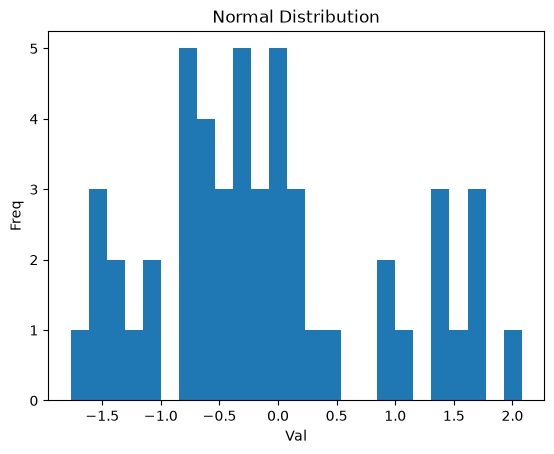

In [101]:
# normal 
data = np.random.normal(loc=0, scale=1, size=50)
plt.hist(data, bins=25)
plt.title("Normal Distribution")
plt.xlabel("Val")
plt.ylabel("Freq")
plt.show()

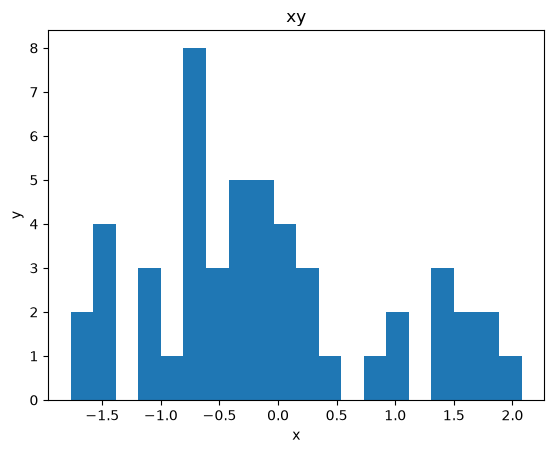

In [102]:
#binomial
data1 = np.random.normal(loc=0, scale=1, size=20)
plt.hist(data, bins=20)
plt.title("xy")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

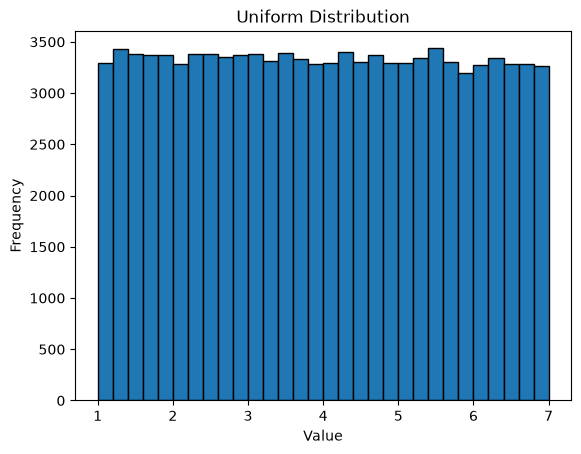

In [103]:
#uniform
samples = np.random.uniform(low=1,high=7,size=100000)

plt.hist(samples, bins=30, edgecolor='black')
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### Hands-On Lab: Probability & Distributions in Code
- Step 1: Simulate 10,000 coin flips with NumPy and confirm the proportion of heads approaches 0.5.

In [104]:
import numpy as np
import matplotlib.pyplot as plt

In [105]:
flips = np.random.choice([0, 1], size=10000)
heads = np.mean(flips) 
print("Proportion of heads:",heads)

Proportion of heads: 0.4917


After 10,000 simulated coin flips, the proportion of heads was about 0.5. This illustrates the Law of Large Numbers: with enough independent trials, observed frequencies converge to the true probability.

- Step 2: Sample from a normal distribution with np.random.normal and plot its histogram to confirm the bell shape.

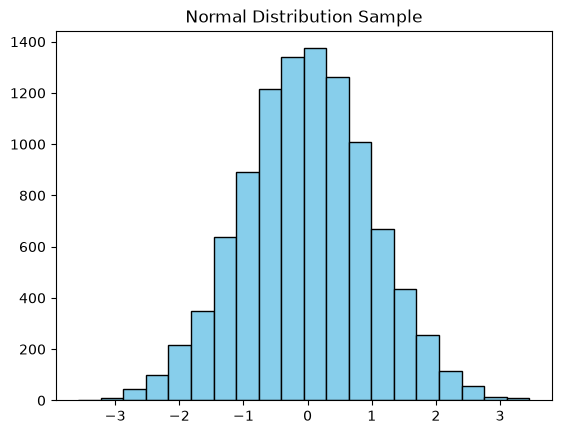

In [106]:

samples = np.random.normal(loc=0, scale=1, size=10000)
plt.hist(samples, bins=20,edgecolor='black',color="skyblue")
plt.title("Normal Distribution Sample")
plt.show()

Sampling 10,000 values from a normal distribution (mean=0, std=1) and plotting a histogram gives the classic bell curve: symmetric, peaking at the mean, and tapering at the tails. This matters in ML because many models assume roughly normal data, making it a key check in EDA.

- Step 3: Given a small worked scenario, compute a conditional probability by hand and verify it with a simulation.


the probapility of flipping a coin and land on head then drawing a king card P(coin is heads AND card is King)

p_coin_head=1/2
p_card_king=4/52
p_headandking=1/2*4/52=1/26


In [107]:
p_heads = 1/2
p_king = 4/52

p_headandking=p_heads*p_king
print(p_headandking)

# P(A|B) = P(A and B) / P(B)
p_heads_king = p_headandking / p_king
print("p_head and king: ",p_heads_king)


0.038461538461538464
p_head and king:  0.5


In [108]:
#simulation
import numpy as np


# Simulate all at once
coins = np.random.choice(["H", "T"], 100000)
kings = np.random.rand(trials) < (4/52)

# Count both events
both = np.sum((coins == "H") & kings)

# Result
print("Simulated P(heads and King):", both / trials)

Simulated P(heads and King): 0.03835


Modeling a coin flip and a card draw (for a King) as independent events gives P(heads and King) = 1/26 ≈ 0.0385. A simulation of 100,000 trials matched this result. Using conditional probability, P(heads | King) = 0.5 — the same as P(heads) — proving the two events are independent.


### Tools Used
NumPy • Matplotlib • Jupyter Notebook